In [49]:
import pandas as pd

# load dataset
df = pd.read_csv("../../data/processed/berlin/urban_dashboard.csv")

# preprocessing
df["avg_travel_time"] = pd.to_timedelta(df["avg_travel_time"])
df["minutes"] = df["avg_travel_time"].dt.total_seconds() / 60

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# chart config
FIG_SIZE = (10, 5)
PALETTE = "viridis"

sns.set_style("whitegrid")

def clean_plot(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    sns.despine()
    plt.tight_layout()

## **NETWORK SCALE & VOLUME - Berlin**

In [51]:
print("Total segments:", len(df))
print("Total trips:", df["trip_count"].sum())

Total segments: 18684
Total trips: 4195358


Insight:

- Berlin’s network operates at a dense urban scale.
- High trip counts reflect frequent service cycles and commuter-driven demand.

## **DEMAND BY MODE**

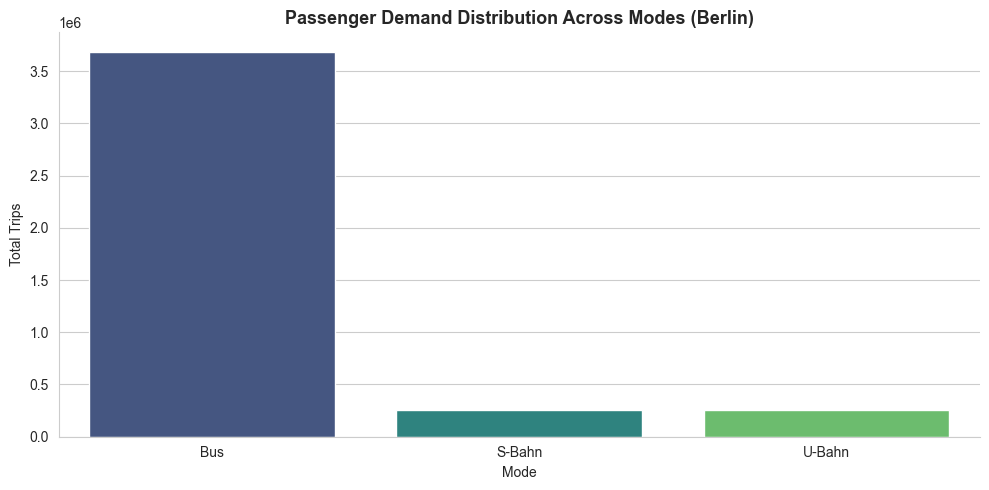

In [52]:
mode_demand = df.groupby("mode")["trip_count"].sum().reset_index()

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=mode_demand,
    x="mode",
    y="trip_count",
    hue="mode",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Passenger Demand Distribution Across Modes (Berlin)",
    "Mode",
    "Total Trips"
)
plt.show()

**Insight:**

- Bus dominates total trips → primary feeder and coverage mode
- S-Bahn & U-Bahn serve structured high-capacity corridors

## **NETWORK COMPOSITION**

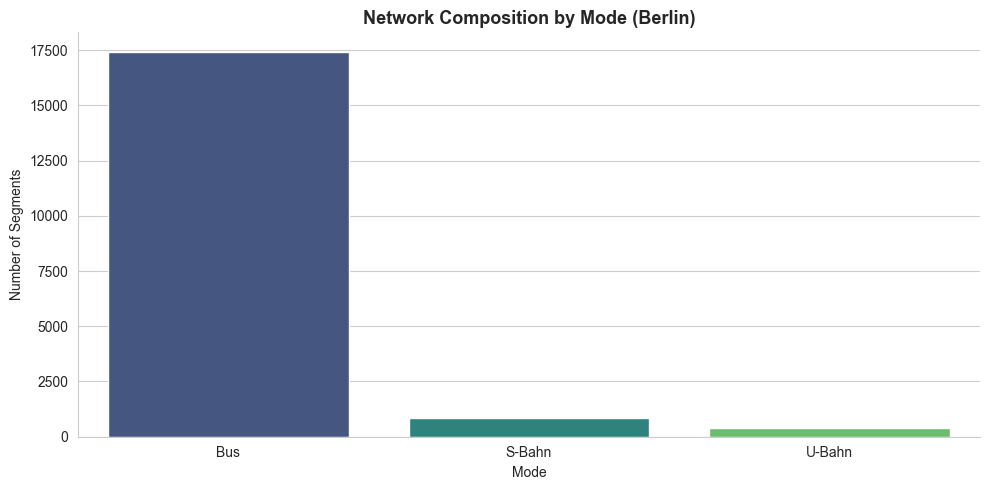

In [53]:
mode_segments = df["mode"].value_counts().reset_index()
mode_segments.columns = ["mode", "count"]

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=mode_segments,
    x="mode",
    y="count",
    hue="mode",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Network Composition by Mode (Berlin)",
    "Mode",
    "Number of Segments"
)
plt.show()

**Insight:**

- Bus network has the highest spatial coverage (many segments)
- Rail modes have fewer segments but higher capacity

## **AVERAGE TRAVEL TIME BY MODE**

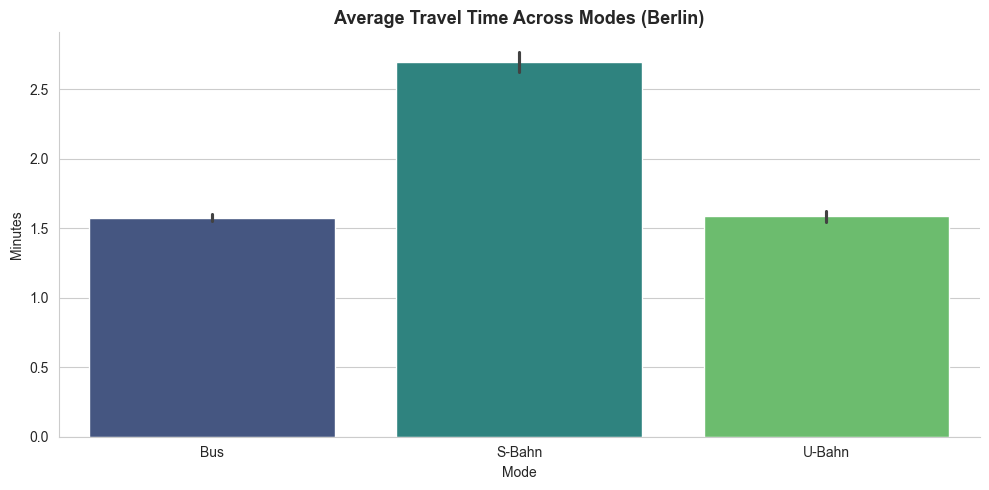

In [54]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=df,
    x="mode",
    y="minutes",
    hue="mode",
    estimator="mean",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Average Travel Time Across Modes (Berlin)",
    "Mode",
    "Minutes"
)
plt.show()

**Insight:**

- S-Bahn shows higher average travel time → longer inter-district travel
- Bus and U-Bahn are optimized for shorter urban trips

## **TRAVEL TIME VARIABILITY**

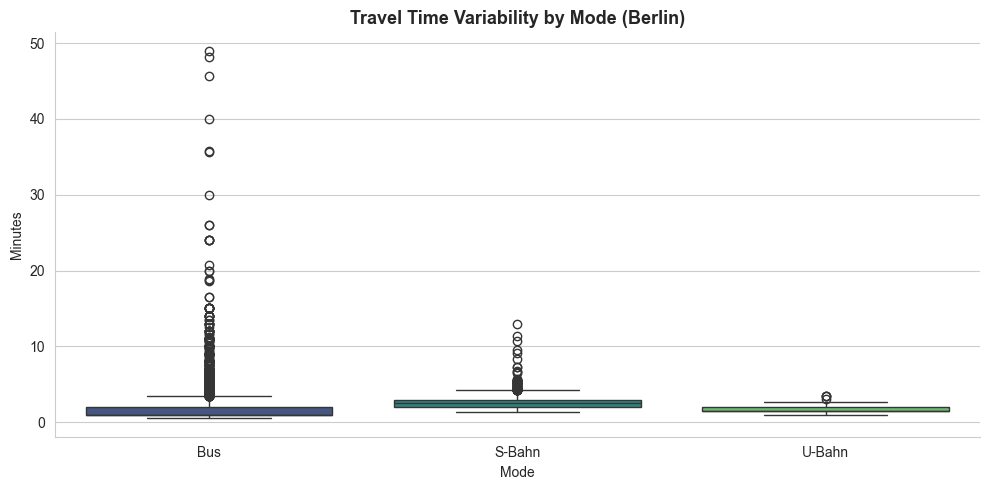

In [55]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.boxplot(
    data=df,
    x="mode",
    y="minutes",
    hue="mode",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Travel Time Variability by Mode (Berlin)",
    "Mode",
    "Minutes"
)
plt.show()

**Insight:**

- Bus shows highest variability → traffic and road dependency
- U-Bahn is most stable → controlled underground system
- S-Bahn sits in between → semi-controlled network

## **BUSIEST SEGMENTS**

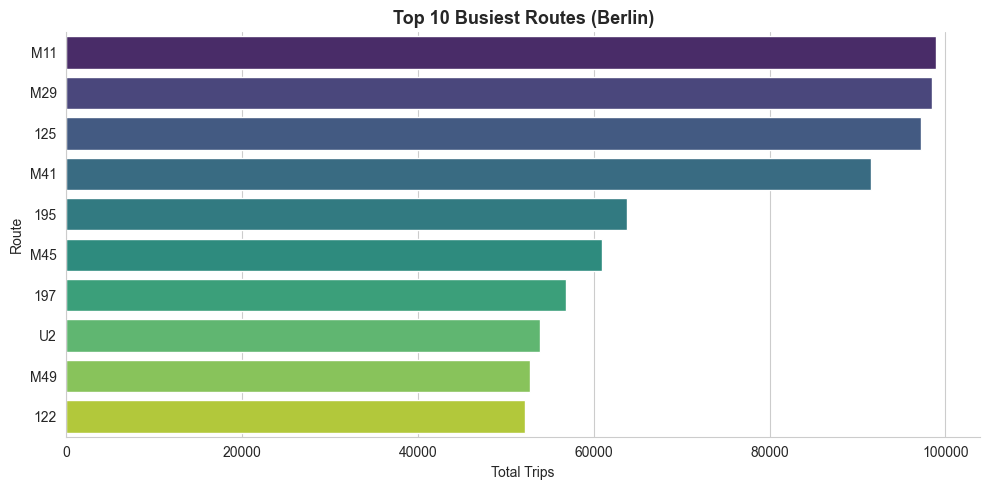

In [56]:
top_segments = (
    df.groupby("route_short_name")["trip_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=top_segments,
    y="route_short_name",
    x="trip_count",
    hue="route_short_name",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Top 10 Busiest Routes (Berlin)",
    "Total Trips",
    "Route"
)

plt.show()

**Insight:**

- High-demand segments are concentrated along key bus corridors
- Reflects strong localized commuter movement

## **STATION CONNECTIVITY**

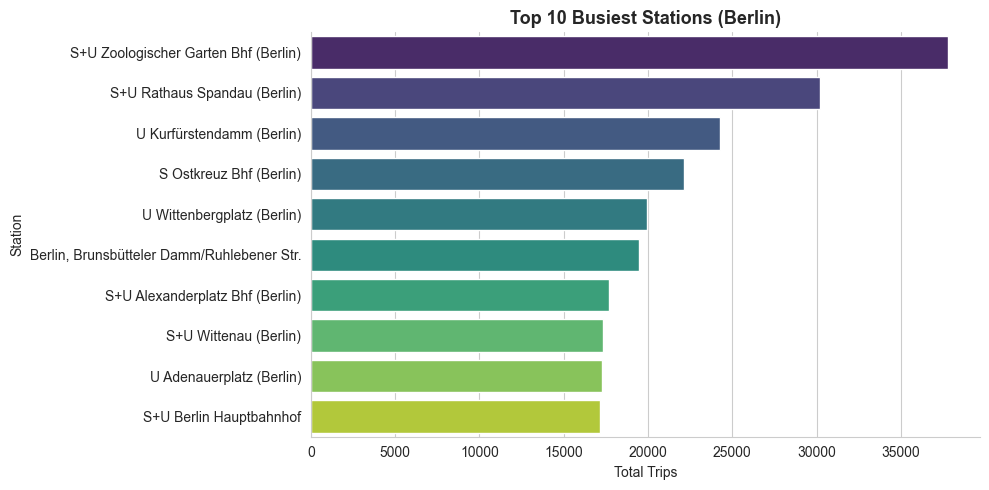

In [57]:
from_counts = df.groupby("from_stop")["trip_count"].sum()
to_counts = df.groupby("to_stop")["trip_count"].sum()

station_usage = (
    from_counts.add(to_counts, fill_value=0)
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

station_usage.columns = ["station", "total_trips"]

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=station_usage,
    y="station",
    x="total_trips",
    hue="station",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Top 10 Busiest Stations (Berlin)",
    "Total Trips",
    "Station"
)
plt.show()

**Insight:**

- Major hubs (Zoo, Spandau, Ostkreuz, Hbf) emerge clearly
- Confirms correct network centrality representation

## **NETWORK INTENSITY**

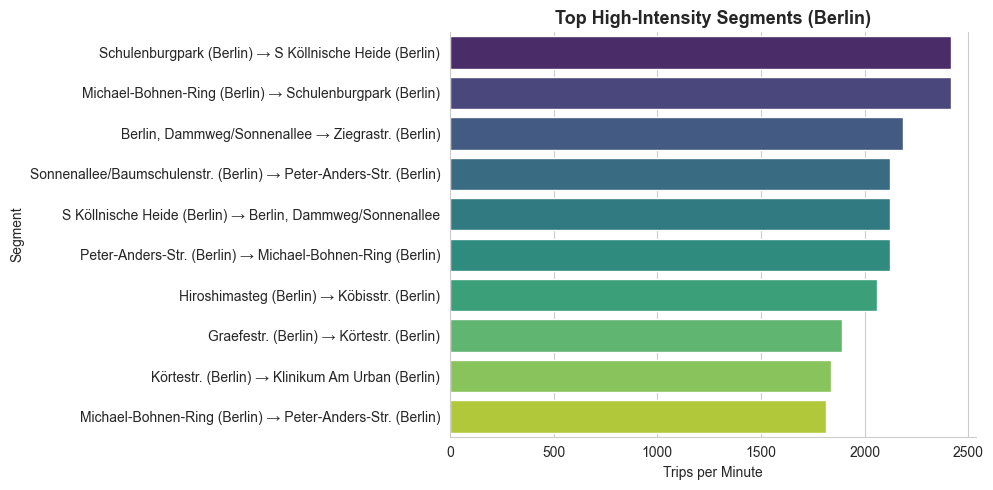

In [58]:
df["intensity"] = df["trip_count"] / df["minutes"]

top_intensity = df.sort_values("intensity", ascending=False).head(10)

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=top_intensity,
    y="segment_id",
    x="intensity",
    hue="segment_id",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Top High-Intensity Segments (Berlin)",
    "Trips per Minute",
    "Segment"
)
plt.show()

**Insight:**

- High-intensity segments combine high frequency + short travel time
- Indicates highly optimized urban corridors

## **STATION IMPORTANCE (CENTRALITY)**

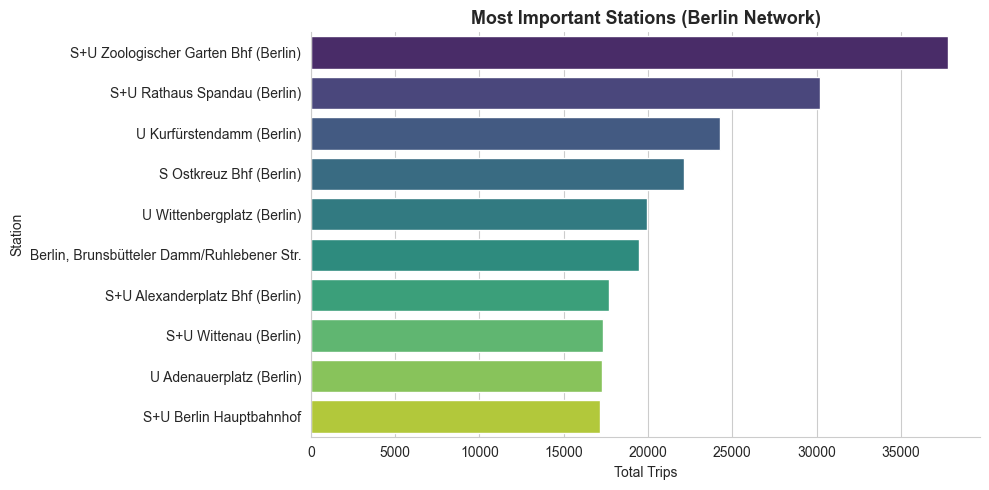

In [59]:
station_importance = (
    from_counts.add(to_counts, fill_value=0)
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

station_importance.columns = ["station", "total_trips"]

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=station_importance,
    y="station",
    x="total_trips",
    hue="station",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Most Important Stations (Berlin Network)",
    "Total Trips",
    "Station"
)
plt.show()

**Insight:**

- These stations act as multi-modal interchange hubs
- Critical for system-wide connectivity and passenger flow


## **Key Insights**

- Berlin’s transport network is highly multimodal, with bus dominating coverage and rail providing structural backbone.

- Bus serves as the primary feeder system, while S-Bahn and U-Bahn handle high-capacity urban movement.

- Travel time patterns reflect functional roles: shorter trips for buses/U-Bahn, longer for S-Bahn.

- Variability highlights reliability differences: U-Bahn is most stable, bus most variable.

- Key stations such as Zoologischer Garten, Ostkreuz, and Berlin Hbf act as central hubs in the network.

- High-intensity segments indicate optimized corridors supporting dense commuter traffic.